<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<div style="text-align: center;">
  <h1>Dividend Taxation and Top-Income Inequality</h1>
  <h3>HEC Liege</h3>
  <h4><em>Lucas Dubois</em></h4>
</div>

<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


In [98]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
df = pd.read_csv(path + "MASTER_FINAL.csv")
df = df.sort_values(["Country Name", "Year"])

In [99]:
offwhite = (230/255, 230/255, 220/255)
midnight = (0/255, 22/255, 36/255)
steelblue = (171/255, 193/255, 223/255)
primaryred = (127/255, 20/255, 22/255)
harmonizedblue =(48/255,88/255,140/255)

In [100]:
inequality_variables = [
    "top10_inc",
    "top1_inc",
    "top10_w",
    "top1_w",
    "gini_disp",
    "gini_mkt",
    "gini_disp_se",
    "gini_mkt_se"
]

interaction_variables = [
    "log_rgdpe",
    "log_pop",
    "log_emp",
    "log_cn",
    "rgdpe_sq",
    "log_rgdpe_sq",
    "hc_ctfp",
    "labsh_irr",
    "cn_ctfp",
    "xr_irr",
    "csh_g_hc",
    "csh_c_hc",
    "rgdpe_ctfp",
    "pop_rgdpe",
    "delta_cn"
]

id_variables = ["Country Name", "Year"]

X = [
    col for col in df.columns
    if col not in inequality_variables + interaction_variables + id_variables
]

X_numeric = df[X].select_dtypes(include=["number"]).columns.tolist()

<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


<div style="text-align: align;">
  <h2> <small>3</small>&nbsp;&nbsp;&nbsp;&nbsp; Beamer:</h2>
</div>

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">

<div style="text-align: align;">
  <h3> <small>3.1</small>&nbsp;&nbsp;&nbsp;&nbsp;Preparing Brazil:</h3>
</div>

In [101]:
# Filter rows where inflation >= 500
filtered_df = df[df['inflation'] >= 50]

# Select only country and year, then sort by year
result = filtered_df[['Country Name', 'Year']].sort_values(by='Country Name')

# Print the result
print(result)

     Country Name  Year
156        Brazil  1985
157        Brazil  1986
158        Brazil  1987
159        Brazil  1988
160        Brazil  1989
161        Brazil  1990
162        Brazil  1991
163        Brazil  1992
164        Brazil  1993
165        Brazil  1994
166        Brazil  1995
556         Ghana  1995
897        Israel  1985
1251      Nigeria  1988
1252      Nigeria  1989
1256      Nigeria  1993
1257      Nigeria  1994
1258      Nigeria  1995


In [102]:
# Brazil series
df2 = pd.read_csv(path + "MASTER_FINAL_ADJ.csv")
df2 = df2.sort_values(["Country Name", "Year"])

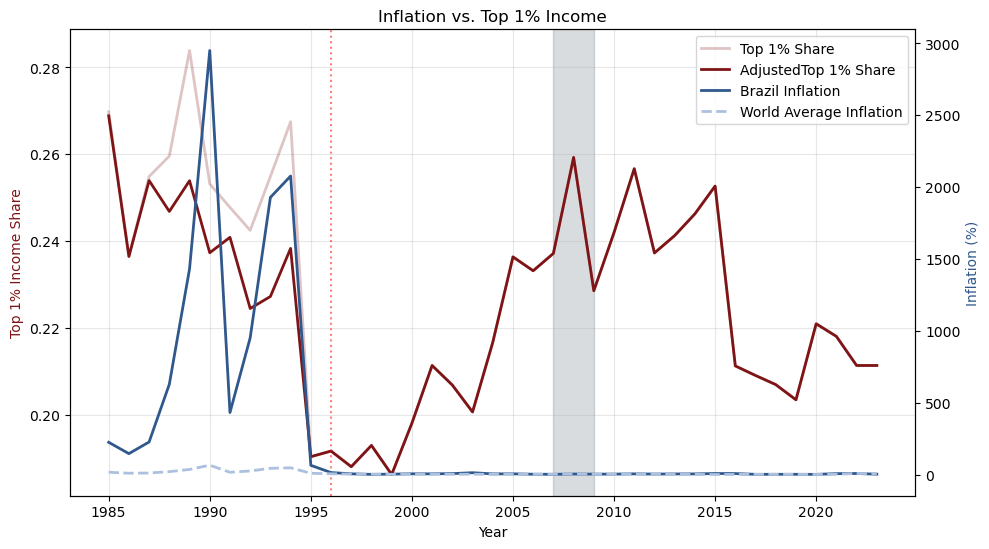

In [103]:
brazil_series_adj=(
    df2[df2["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

brazil_series = (
    df[df["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

brazil_inflation = (
    df[df["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["inflation"]
)

# World average inflation by year
world_avg_inflation = (
    df.groupby("Year")["inflation"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5.6))

# Left axis → Top 1% income
ax.plot(
    brazil_series.index,
    brazil_series.values,
    label='Top 1% Share',
    color=primaryred,
    alpha=0.25,
    linewidth=2
)

ax.plot(
    brazil_series_adj.index,
    brazil_series_adj.values,
    label='AdjustedTop 1% Share',
    color=primaryred,
    linewidth=2
)
ax.set_ylabel('Top 1% Income Share', color=primaryred)

# Right axis → Inflation
ax2 = ax.twinx()

ax2.plot(
    brazil_inflation.index,
    brazil_inflation.values,
    label='Brazil Inflation',
    color=harmonizedblue,
    linewidth=2
)

ax2.plot(
    world_avg_inflation.index,
    world_avg_inflation.values,
    label='World Average Inflation',
    color=steelblue,
    linestyle='--',
    linewidth=2
)

ax2.set_ylabel('Inflation (%)', color=harmonizedblue)

# Vertical lines & shaded areas
ax.axvline(1996, color="red", linestyle=":", alpha=0.5)
ax.axvspan(2007, 2009, color=midnight, alpha=0.15)

# Title & labels
ax.set_xlabel('Year')
ax.set_title("Inflation vs. Top 1% Income")

# Combine legends from both axes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2)

ax.grid(True, alpha=0.3)

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/brazil_inflation_x_topinc.png",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [104]:
df1= pd.read_csv(path + "master_final_raw.csv")

In [105]:
# Filter rows where inflation >= 500
filtered_df1 = df1[df1['inflation'] >= 500]

# Select only country and year, then sort by year
result1 = filtered_df1[['Country Name', 'Year']].sort_values(by='Country Name')

# Print the result
print(result1)

                                        Country Name  Year
469                                           Angola  1993
470                                           Angola  1994
471                                           Angola  1995
472                                           Angola  1996
841                                          Armenia  1994
1183                                      Azerbaijan  1993
1184                                      Azerbaijan  1994
1622                                         Belarus  1993
1623                                         Belarus  1994
1624                                         Belarus  1995
2053                                         Bolivia  1984
2054                                         Bolivia  1985
2408                                          Brazil  1988
2409                                          Brazil  1989
2410                                          Brazil  1990
2412                                          Brazil  19

Pre-treatment RMSE: 0.016093022456364823
Top weights:
 Thailand       6.107938e-01
Madagascar     2.255698e-01
Iran           1.636364e-01
Hungary        2.518952e-18
Netherlands    2.301512e-18
South Korea    2.196193e-18
Norway         2.146595e-18
Iceland        2.095960e-18
Italy          2.038700e-18
Australia      2.034850e-18
dtype: float64
Pre-treatment RMSE: 0.004763222386900163
Top weights:
 Sri Lanka      3.290251e-01
Nepal          1.794558e-01
Germany        1.607500e-01
Luxembourg     1.488079e-01
Finland        9.891697e-02
Botswana       5.255359e-02
Philippines    3.049068e-02
Madagascar     6.003299e-19
Brazil         4.997828e-19
Iran           4.063009e-19
dtype: float64


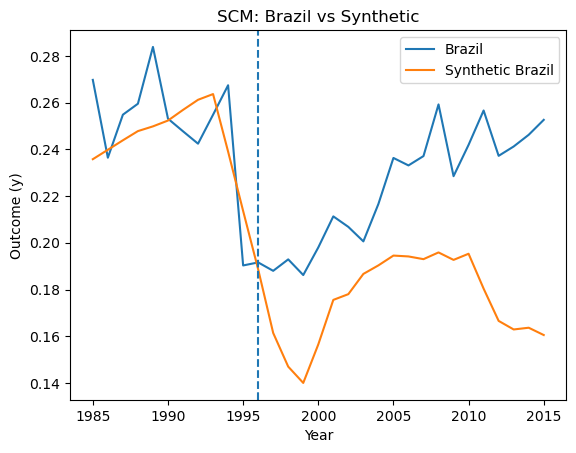

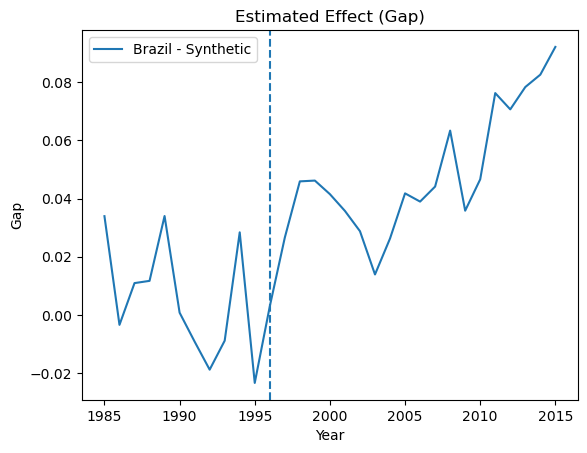

Top donor weights:
Madagascar        7.521741e-01
Thailand          2.478259e-01
Finland           2.625052e-19
Netherlands       2.439220e-19
Hungary           2.378377e-19
Norway            2.359658e-19
Australia         2.239122e-19
Iceland           2.212409e-19
Italy             2.180912e-19
Sweden            2.178890e-19
South Korea       2.171097e-19
Denmark           2.143649e-19
Belgium           2.136802e-19
United Kingdom    2.129805e-19
France            2.046504e-19
dtype: float64
Countries to drop: ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Brazil', 'Bulgaria', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Chad', 'Chile', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', 'Cuba', 'DR Congo', 'Djibouti', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Georgia', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Iraq', 'Jamaica', 'Kos

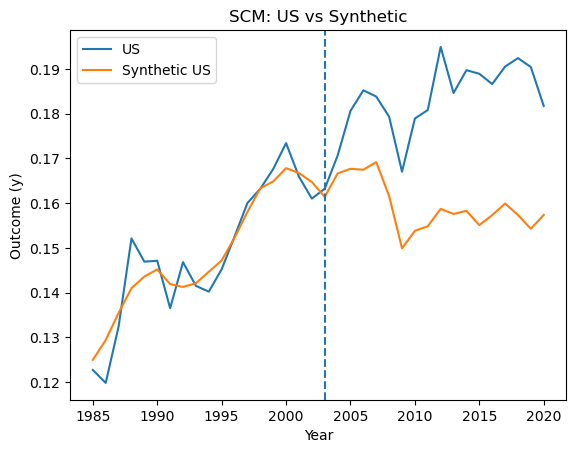

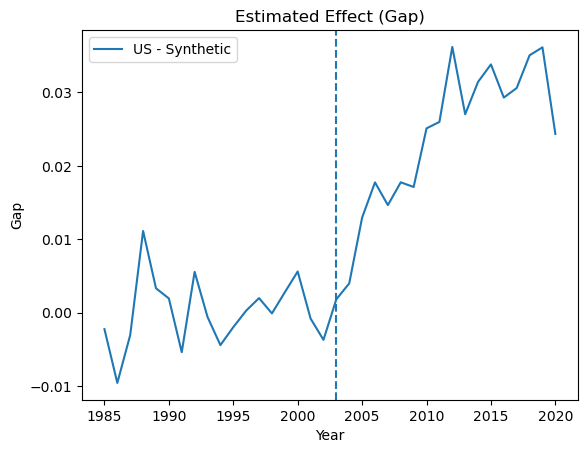

Top donor weights:
Sri Lanka             3.781993e-01
Germany               1.663113e-01
Nepal                 1.427078e-01
Finland               1.347237e-01
Luxembourg            1.107058e-01
Russian Federation    2.826250e-02
Malawi                2.493523e-02
Australia             1.415421e-02
Madagascar            9.282454e-19
Ethiopia              9.018890e-19
Eritrea               9.018890e-19
Indonesia             6.363539e-19
Ukraine               6.044803e-19
Peru                  5.884369e-19
Thailand              5.797697e-19
dtype: float64
Sum of ALL weights: 0.9999999999999997
Min weight: -3.796844935102542e-19
Any negative weights? False
Sum of top 15 weights: 0.9999999999999997
Number of donors: 200
Number of ~zero weights (<1e-8): 192
Pre-treatment RMSE (SCM):  0.0201
Pre-treatment RMSE (ASCM): 0.0194


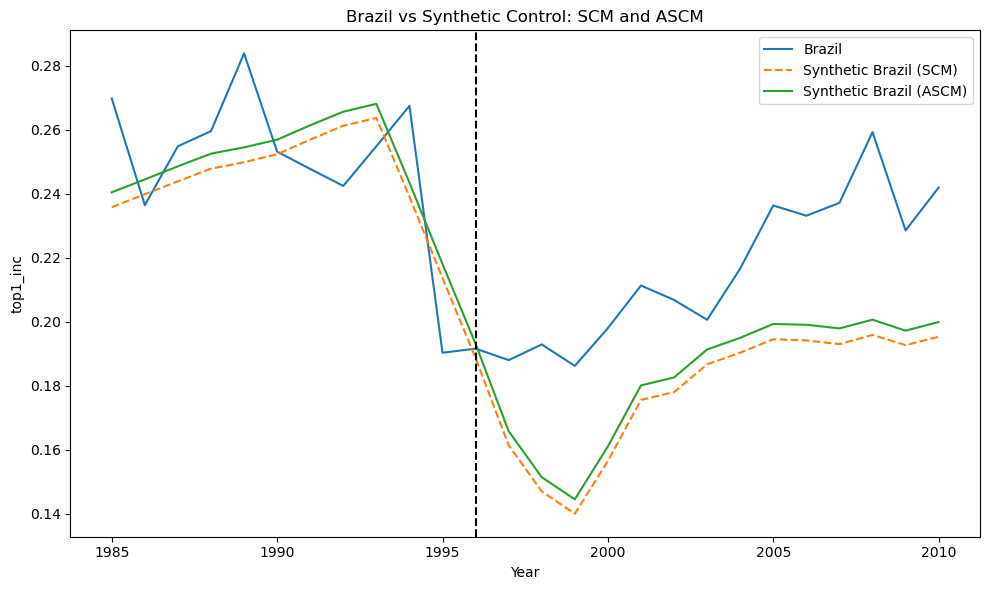

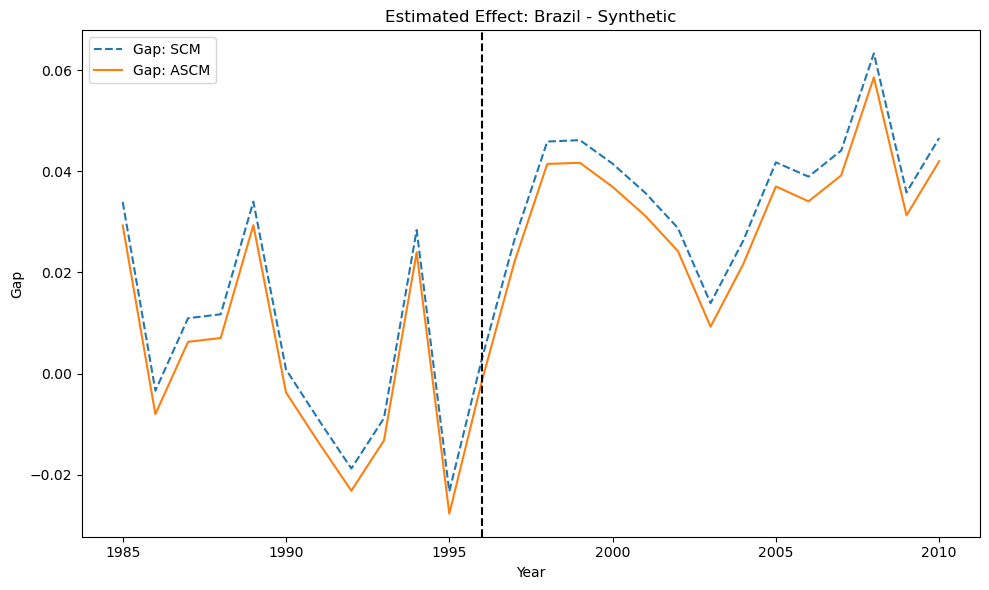


Top SCM donor weights:
Madagascar        7.521741e-01
Thailand          2.478259e-01
Finland           2.625052e-19
Netherlands       2.439220e-19
Hungary           2.378377e-19
Norway            2.359658e-19
Australia         2.239122e-19
Iceland           2.212409e-19
Italy             2.180912e-19
Sweden            2.178890e-19
South Korea       2.171097e-19
Denmark           2.143649e-19
Belgium           2.136802e-19
United Kingdom    2.129805e-19
France            2.046504e-19
dtype: float64

Top ASCM donor weights:
Madagascar     0.753453
Thailand       0.249595
Iran           0.002348
Grenada        0.001675
Dominica       0.001675
Japan          0.001391
Switzerland    0.001367
Malaysia       0.001258
Sweden         0.001208
Germany        0.001178
Singapore      0.001101
Ghana          0.001071
Belgium        0.001015
Botswana       0.000947
Finland        0.000905
dtype: float64

ASCM weights can be negative:
Hungary           -0.001449
Nepal             -0.001342
New Zeala

In [106]:
%run Master_3_SCM.ipynb

In [107]:
print(brazil_scm.keys())

dict_keys(['country', 'weights', 'synthetic', 'effect', 'pre_sse', 'pre_rmse', 'pre_residuals'])


In [108]:
%run Master_4_ASCM_Ridge.ipynb

Pre-treatment RMSE (SCM):  0.0243
Pre-treatment RMSE (ASCM): 0.0160

Top SCM donor weights:
Thailand         1.000000e+00
Botswana         4.016304e-14
Madagascar       3.936356e-14
Iran            -3.264371e-13
Philippines     -6.594748e-13
United States   -8.210616e-13
Malaysia        -8.580437e-13
India           -1.029459e-12
Israel          -1.199835e-12
Fiji            -1.201166e-12
Luxembourg      -1.266071e-12
Iceland         -1.535835e-12
Pakistan        -1.587732e-12
Egypt           -1.639256e-12
Nepal           -1.665763e-12
dtype: float64

Top ASCM donor weights:
Thailand         1.017434
Madagascar       0.251393
Norway           0.120465
Japan            0.092460
Belgium          0.091888
New Zealand      0.085490
Germany          0.082650
United States    0.055207
Singapore        0.052334
Canada           0.051964
South Korea      0.047968
Iran             0.032154
Sri Lanka        0.025397
Hong Kong        0.021069
Israel           0.018925
dtype: float64

Most negativ

In [109]:
brazil_ascm = scm_ascm(
    df=df,
    country="Brazil",
    treat_year=1996,
    covariates=covariates,
    ridge_lambda=1.0
)

Pre-treatment RMSE (SCM):  0.0243
Pre-treatment RMSE (ASCM): 0.0160

Top SCM donor weights:
Thailand         1.000000e+00
Botswana         4.016304e-14
Madagascar       3.936356e-14
Iran            -3.264371e-13
Philippines     -6.594748e-13
United States   -8.210616e-13
Malaysia        -8.580437e-13
India           -1.029459e-12
Israel          -1.199835e-12
Fiji            -1.201166e-12
Luxembourg      -1.266071e-12
Iceland         -1.535835e-12
Pakistan        -1.587732e-12
Egypt           -1.639256e-12
Nepal           -1.665763e-12
dtype: float64

Top ASCM donor weights:
Thailand         1.017434
Madagascar       0.251393
Norway           0.120465
Japan            0.092460
Belgium          0.091888
New Zealand      0.085490
Germany          0.082650
United States    0.055207
Singapore        0.052334
Canada           0.051964
South Korea      0.047968
Iran             0.032154
Sri Lanka        0.025397
Hong Kong        0.021069
Israel           0.018925
dtype: float64

Most negativ

In [110]:
print(weights_ascm)

Madagascar         0.753453
Thailand           0.249595
Iran               0.002348
Grenada            0.001675
Dominica           0.001675
Japan              0.001391
Switzerland        0.001367
Malaysia           0.001258
Sweden             0.001208
Germany            0.001178
Singapore          0.001101
Ghana              0.001071
Belgium            0.001015
Botswana           0.000947
Finland            0.000905
Egypt              0.000892
Hong Kong          0.000865
Pakistan           0.000851
Spain              0.000842
South Korea        0.000837
Denmark            0.000813
Cyprus             0.000757
Israel             0.000630
Luxembourg         0.000625
Nigeria            0.000617
Tanzania           0.000605
Sri Lanka          0.000561
Austria            0.000559
Netherlands        0.000522
United States      0.000492
India              0.000464
Greece             0.000459
Australia          0.000456
Iceland            0.000451
United Kingdom     0.000291
Norway             0

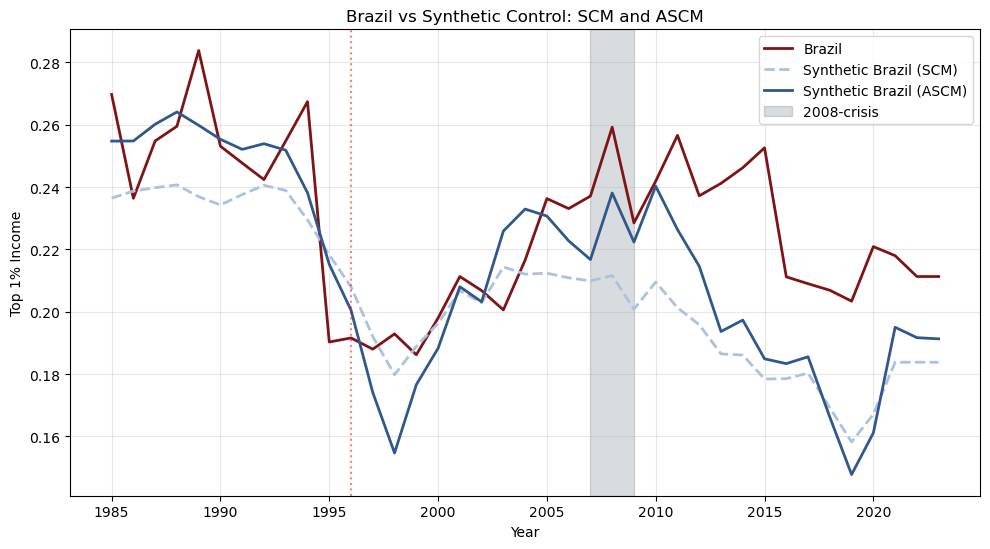

In [111]:
brazil_series = (
    df[df["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

fig, ax = plt.subplots(figsize=(10, 5.6))

# Actual Brazil
ax.plot(
    brazil_series.index,
    brazil_series.values,
    label='Brazil',
    color=primaryred,
    linewidth=2
)

# SCM
ax.plot(
    brazil_scm["synthetic"].index,
    brazil_scm["synthetic"].values,
    label='Synthetic Brazil (SCM)',
    linestyle='--',
    color=steelblue,
    linewidth=2
)

# ASCM
ax.plot(
    brazil_ascm["synthetic_ascm"].index,
    brazil_ascm["synthetic_ascm"].values,
    label='Synthetic Brazil (ASCM)',
    color=harmonizedblue,
    linewidth=2
)

ax.axvline(1996, color="red", linestyle=":", alpha=0.5)
ax.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

ax.set_xlabel('Year')
ax.set_ylabel('Top 1% Income')
ax.set_title("Brazil vs Synthetic Control: SCM and ASCM")

ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/brazil_scm_ascm.png",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.tight_layout()
plt.show()
plt.close(fig)

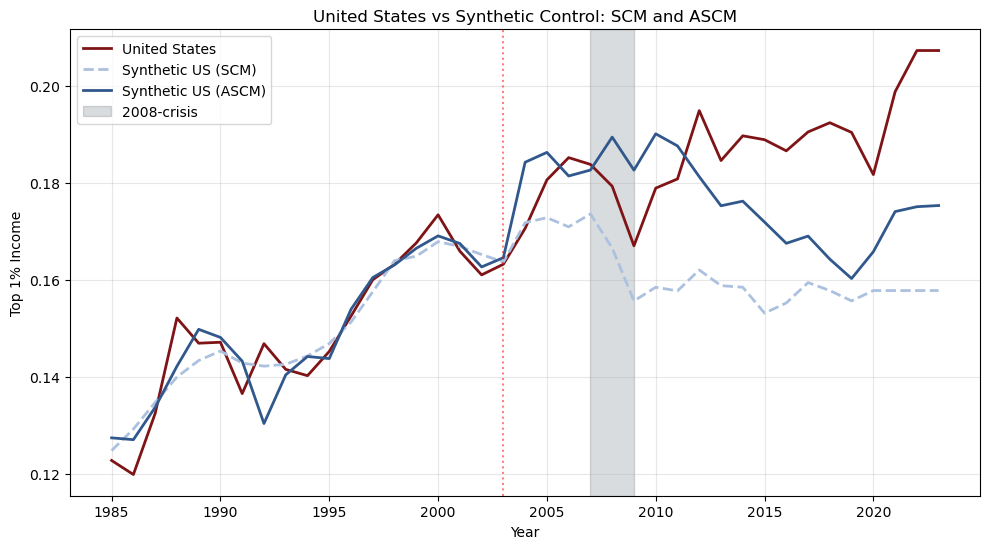

In [113]:
us_series = (
    df[df["Country Name"] == "United States"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

fig, ax = plt.subplots(figsize=(10, 5.6))

# Actual US
ax.plot(
    us_series.index,
    us_series.values,
    label='United States',
    color=primaryred,
    linewidth=2
)

# SCM
ax.plot(
    us_scm["synthetic"].index,
    us_scm["synthetic"].values,
    label='Synthetic US (SCM)',
    linestyle='--',
    color=steelblue,
    linewidth=2
)

# ASCM
ax.plot(
    usa_ascm["synthetic_ascm"].index,
    usa_ascm["synthetic_ascm"].values,
    label='Synthetic US (ASCM)',
    color=harmonizedblue,
    linewidth=2
)

# Treatment + crisis
ax.axvline(2003, color="red", linestyle=":", alpha=0.5)
ax.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

# Labels
ax.set_xlabel('Year')
ax.set_ylabel('Top 1% Income')
ax.set_title("United States vs Synthetic Control: SCM and ASCM")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/us_scm_ascm.png",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close(fig)